### Распределение эмбеддингов текстов. 
Энкодер: all-mpnet-base-v2

In [1]:
SEED = 42
ENCODER = "sentence-transformers/all-mpnet-base-v2"
MAX_HUMAN_SAMPLES = 10000

MAX_VIS_SAMPLES = 2000

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.covariance import LedoitWolf
from sklearn.metrics import roc_auc_score, f1_score, roc_curve, precision_recall_curve, average_precision_score
from sklearn.decomposition import PCA
from scipy.special import softmax
from random import sample
from scipy.stats import skew, kurtosis
import torch
from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm

In [3]:
# https://huggingface.co/sentence-transformers/all-mpnet-base-v2

def mean_pooling(model_output, attention_mask):
    token_embeddings = model_output[0]
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
        
    return torch.sum(token_embeddings * input_mask_expanded, 1) / torch.clamp(input_mask_expanded.sum(1), min=1e-9)

    
def get_embeddings(tokenizer, model, df, batch_size=16, device=None):
    if device is None:
        device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
    
    model.to(device)
    model.eval()
    all_embeddings = []

    for i in tqdm(range(0, len(df), batch_size)):
        batch_texts = df[i:i + batch_size].tolist()
        encoded_input = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            return_tensors='pt'
        )

        encoded_input = {k: v.to(device) for k, v in encoded_input.items()}

        with torch.no_grad():
            model_output = model(**encoded_input)
            embeddings = mean_pooling(model_output, encoded_input['attention_mask'])

        all_embeddings.append(embeddings.cpu())

        if device.type == "mps":
            torch.mps.empty_cache()

    all_embeddings = torch.cat(all_embeddings, dim=0)
    return all_embeddings


In [4]:
sns.set(style="whitegrid")

def subsample(X_h, X_ai, max_samples):
    idx_h = list(range(len(X_h)))
    idx_ai = list(range(len(X_ai)))

    if len(idx_h) > max_samples // 2:
        idx_h = sample(idx_h, max_samples // 2)
    if len(idx_ai) > max_samples // 2:
        idx_ai = sample(idx_ai, max_samples // 2)

    X = np.vstack([X_h[idx_h], X_ai[idx_ai]])
    y = np.concatenate([np.zeros(len(idx_h)), np.ones(len(idx_ai))])

    return X, y


def plot_mahalanobis_distributions(scores_human, scores_ai, name):
    plt.figure(figsize=(8, 5))

    all_scores = np.concatenate([scores_human, scores_ai])
    bins = np.histogram_bin_edges(all_scores, bins="auto")

    plt.hist(scores_human, bins=bins, density=True, alpha=0.6, label="Человек")
    plt.hist(scores_ai, bins=bins, density=True, alpha=0.6, label="ИИ")

    plt.title(f"Распределение расстояния Махаланобиса (набор '{name}')")
    plt.xlabel("Квадрат расстояния Махаланобиса")
    plt.ylabel("Плотность")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    
    plt.show()


def plot_roc_curve(y_true, scores, roc_auc, name):
    fpr, tpr, _ = roc_curve(y_true, scores)
    
    plt.figure(figsize=(8, 5))
    plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
    plt.xlabel("False Positive Rate (FPR)")
    plt.ylabel("True Positive Rate TPR")
    plt.title(f"ROC-кривая ('{name}')")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    
    plt.show()


def plot_pca_projection(X_human, X_ai, name):
    X, y = subsample(X_human, X_ai, MAX_VIS_SAMPLES)
    X_2d = PCA(n_components=2, random_state=SEED).fit_transform(X)

    plt.figure(figsize=(8, 5))
    scatter = sns.scatterplot(
        x=X_2d[:, 0], y=X_2d[:, 1],
        hue=y, palette={0: "blue", 1: "orange"},
        alpha=0.5, s=35
    )
    plt.title(f"Проекция PCA (dataset '{name}')")

    handles, _ = scatter.get_legend_handles_labels()
    plt.legend(handles=handles, labels=["Человек", "ИИ"])
    plt.tight_layout()
    
    plt.show()


def print_header(title, char="="):
    print(f"\n{char * 100}")
    print(title)
    print(f"{char * 100}")


def print_subheader(title):
    print(f"\n--- {title} ---")


def print_kv(key, value, width=35):
    print(f"{key:<{width}}: {value}")


def covariance_spectrum(cov, top_k=100):
    C = cov.covariance_
    
    eigvals = np.linalg.eigvalsh(C)
    eigvals = eigvals[::-1]
    
    explained = eigvals / eigvals.sum()
    cumulative = np.cumsum(explained)

    fig, ax = plt.subplots(2, 1, figsize=(8, 8))

    ax[0].bar(range(1, top_k + 1), explained[:top_k])
    ax[0].set_title("Объясненная дисперсия (первые компоненты)")
    ax[0].set_xlabel("Номер компоненты")
    ax[0].set_ylabel("Доля объясненной дисперсии")

    ax[1].plot(range(1, top_k + 1), cumulative[:top_k], marker="o")
    ax[1].axhline(0.9, color="r", linestyle="--", label="90%")
    ax[1].axhline(0.95, color="g", linestyle="--", label="95%")
    ax[1].set_title("Накопленная объясненная дисперсия")
    ax[1].set_xlabel("Число компонент")
    ax[1].set_ylabel("Накопленная доля дисперсии")
    ax[1].legend()

    plt.tight_layout()
    plt.show()
    

def print_mahalanobis_stats(scores, label, width=50, precision=4):
    stats = {
        "Среднее": scores.mean(),
        "Стд. отклонение": scores.std(),
        "Асимметрия": skew(scores),
        "Эксцесс": kurtosis(scores),
        "95% квантиль": np.quantile(scores, 0.95),
        "99% квантиль": np.quantile(scores, 0.99),
    }
    
    print(f"Статистики расстояния Махаланобиса ({label})")
    print("=" * width)
    for k, v in stats.items():
        print(f"{k:<18s} | {v:>{width-22}.{precision}f}")
    print("=" * width)
    print("")


def print_norm_stats(X, precision=4):
    norms = np.linalg.norm(X, axis=1)
    
    stats = {
        "Среднее значение нормы": norms.mean(),
        "Стандартное отклонение": norms.std(),
    }
        
    print("Статистики норм векторов")
    print("=" * 32)
    for k, v in stats.items():
        print(f"{k:<24s}: {v:.{precision}f}")
    print("=" * 32)
    print("")

In [5]:
human_df = (
    pd.read_csv("../datasets/ivy_panda_essays.csv", encoding="utf-8")
    .assign(label=0)[["text", "label"]]
    .reset_index(drop=True)
)

if MAX_HUMAN_SAMPLES is not None:
    human_df = human_df.sample(n=MAX_HUMAN_SAMPLES, random_state=SEED)

print(f"Живых текстов: {len(human_df)}")

Живых текстов: 10000


In [6]:
filenames = {
    "Mistral 7B 1": "../datasets/mistral_essays_1.csv",
    "Mistral 7B 2": "../datasets/mistral_essays_2.csv",
    "Mistral 7B 3": "../datasets/mistral_essays_3.csv",
    "Mistral 7B 4": "../datasets/mistral_essays_4.csv",
    "Mistral 7B 5": "../datasets/mistral_essays_5.csv",
    "Llama 3 13B 1": "../datasets/llama_essays_1.csv",
    "Llama 3 13B 2": "../datasets/llama_essays_2.csv",
    "Llama 3 13B 3": "../datasets/llama_essays_3.csv",
    "Llama 3 13B 4": "../datasets/llama_essays_4.csv",
    "Llama 3 13B 5": "../datasets/llama_essays_5.csv",
    "DeepSeek V3.2 1": "../datasets/deepseek_essays_1.csv",
    "DeepSeek V3.2 2": "../datasets/deepseek_essays_2.csv",
    "DeepSeek V3.2 3": "../datasets/deepseek_essays_3.csv",
    "DeepSeek V3.2 4": "../datasets/deepseek_essays_4.csv",
    "DeepSeek V3.2 5": "../datasets/deepseek_essays_5.csv",
    "ChatGPT 1": "../datasets/chatgpt_essays_1.csv",
    "ChatGPT 2": "../datasets/chatgpt_essays_2.csv",
    "ChatGPT 3": "../datasets/chatgpt_essays_3.csv",
    "ChatGPT 4": "../datasets/chatgpt_essays_4.csv",
    "ChatGPT 5": "../datasets/chatgpt_essays_5.csv",
}

ai_datasets = {}
for name, fn in filenames.items():
    df = pd.read_csv(fn, encoding="utf-8").assign(label=1)[["text", "label"]].reset_index(drop=True)
    ai_datasets[name] = df
    print(f"Загружен датасет '{name}'. {len(df)} записей")

Загружен датасет 'Mistral 7B 1'. 1500 записей
Загружен датасет 'Mistral 7B 2'. 1500 записей
Загружен датасет 'Mistral 7B 3'. 1500 записей
Загружен датасет 'Mistral 7B 4'. 1500 записей
Загружен датасет 'Mistral 7B 5'. 1500 записей
Загружен датасет 'Llama 3 13B 1'. 999 записей
Загружен датасет 'Llama 3 13B 2'. 1000 записей
Загружен датасет 'Llama 3 13B 3'. 994 записей
Загружен датасет 'Llama 3 13B 4'. 997 записей
Загружен датасет 'Llama 3 13B 5'. 999 записей
Загружен датасет 'DeepSeek V3.2 1'. 3000 записей
Загружен датасет 'DeepSeek V3.2 2'. 3000 записей
Загружен датасет 'DeepSeek V3.2 3'. 2999 записей
Загружен датасет 'DeepSeek V3.2 4'. 3000 записей
Загружен датасет 'DeepSeek V3.2 5'. 3000 записей
Загружен датасет 'ChatGPT 1'. 2000 записей
Загружен датасет 'ChatGPT 2'. 2000 записей
Загружен датасет 'ChatGPT 3'. 2000 записей
Загружен датасет 'ChatGPT 4'. 2000 записей
Загружен датасет 'ChatGPT 5'. 2000 записей



ENCODER: sentence-transformers/all-mpnet-base-v2


100%|█████████████████████████████████████████| 625/625 [09:31<00:00,  1.09it/s]


Статистики норм векторов
Среднее значение нормы  : 2.3587
Стандартное отклонение  : 0.1253

Эмбеддинги живых текстов (train)   : 7000
Эмбеддинги живых текстов (test)    : 3000


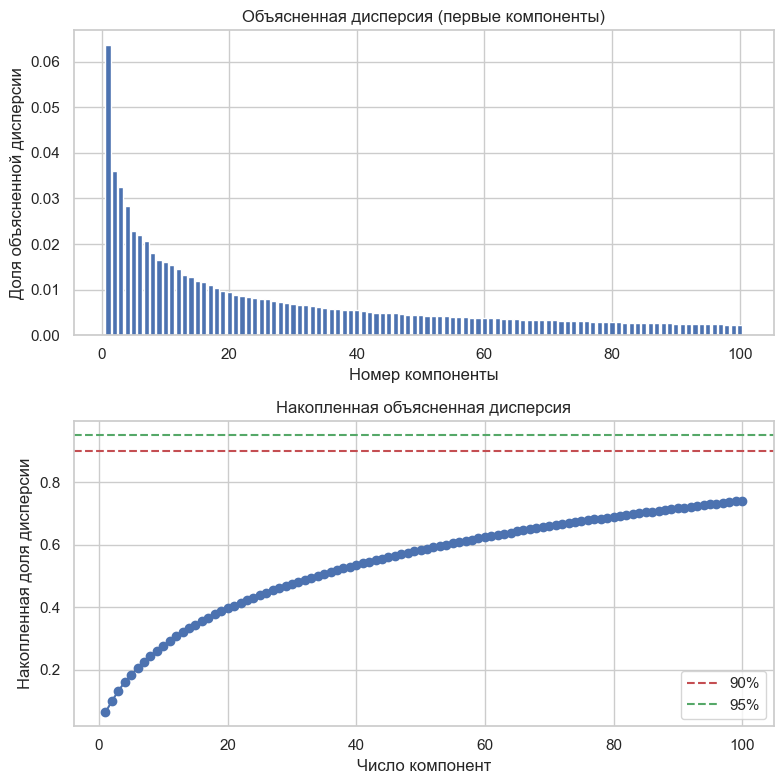


Набор: Mistral 7B 1
----------------------------------------


100%|███████████████████████████████████████████| 94/94 [01:26<00:00,  1.09it/s]


Статистики расстояния Махаланобиса (человек)
Среднее            |                     745.4394
Стд. отклонение    |                     292.3279
Асимметрия         |                       1.7572
Эксцесс            |                       4.6447
95% квантиль       |                    1296.6237
99% квантиль       |                    1781.0974

Статистики расстояния Махаланобиса (ии)
Среднее            |                     857.6956
Стд. отклонение    |                     353.1276
Асимметрия         |                       2.0120
Эксцесс            |                       7.0624
95% квантиль       |                    1541.5054
99% квантиль       |                    2111.5054

Количество объектов в 0 классе     : 3000
Количество объектов в 1 классе     : 1500
ROC-AUC                            : 0.6080
PR-AUC                             : 0.5920


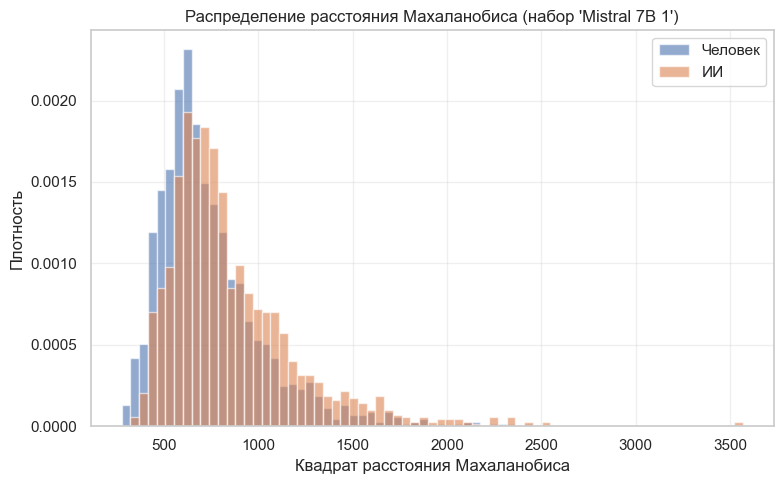

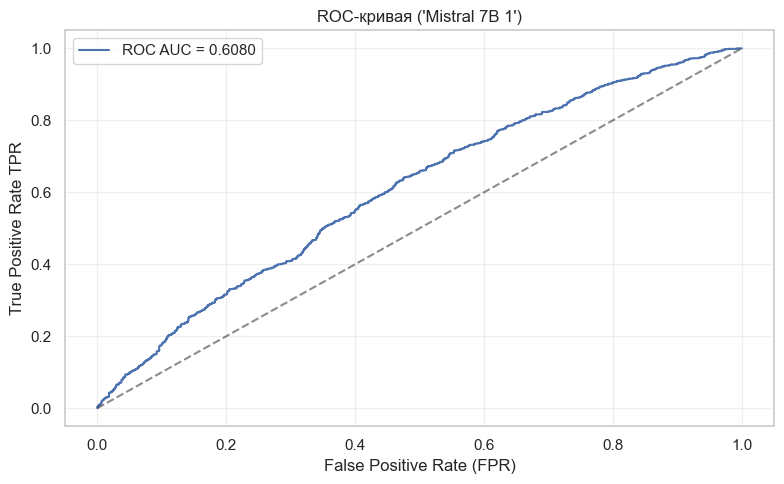

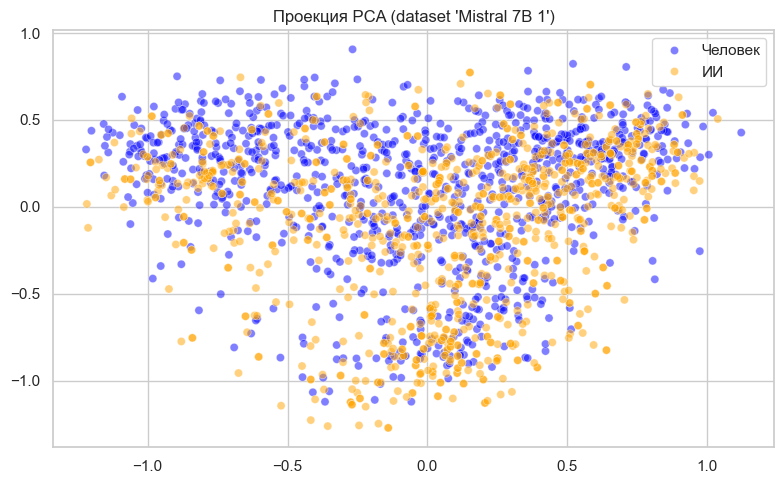


Набор: Mistral 7B 2
----------------------------------------


100%|███████████████████████████████████████████| 94/94 [01:45<00:00,  1.12s/it]


Статистики расстояния Махаланобиса (человек)
Среднее            |                     745.4394
Стд. отклонение    |                     292.3279
Асимметрия         |                       1.7572
Эксцесс            |                       4.6447
95% квантиль       |                    1296.6237
99% квантиль       |                    1781.0974

Статистики расстояния Махаланобиса (ии)
Среднее            |                     879.3984
Стд. отклонение    |                     354.7322
Асимметрия         |                       2.6958
Эксцесс            |                      17.9895
95% квантиль       |                    1537.7839
99% квантиль       |                    2079.9241

Количество объектов в 0 классе     : 3000
Количество объектов в 1 классе     : 1500
ROC-AUC                            : 0.6371
PR-AUC                             : 0.6090


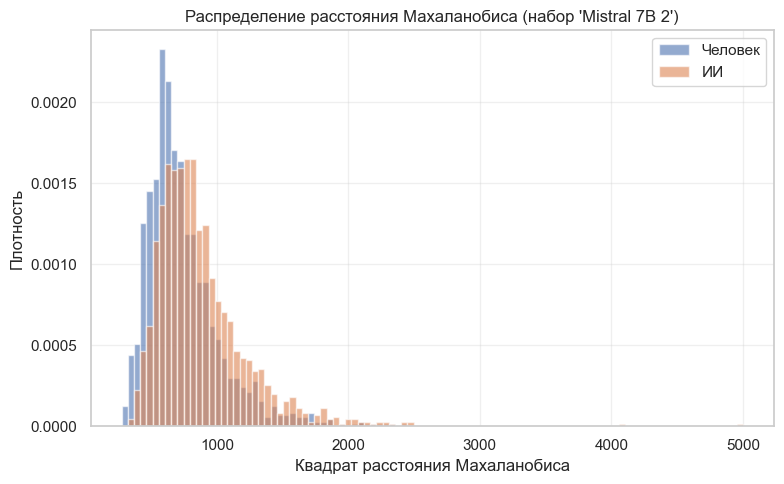

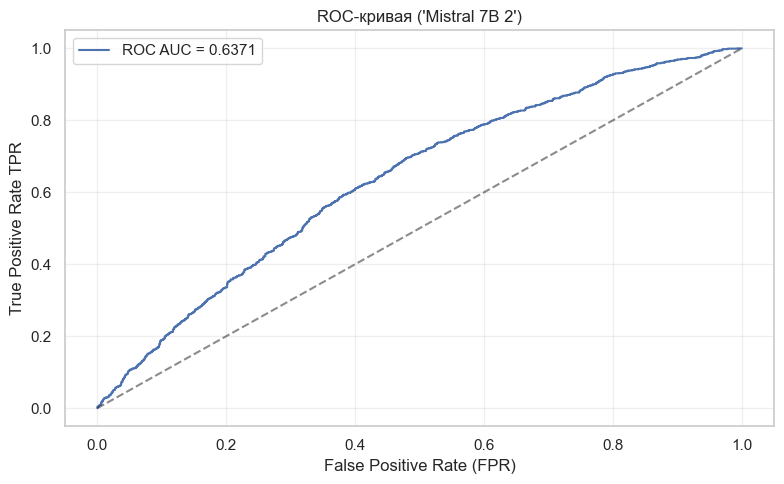

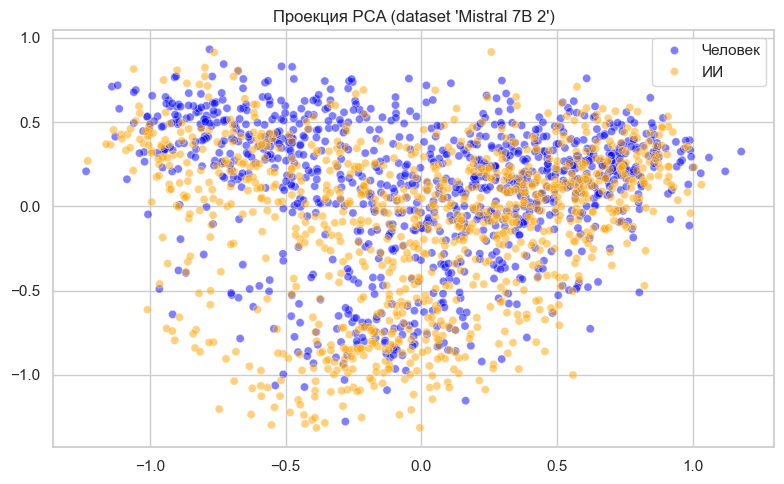


Набор: Mistral 7B 3
----------------------------------------


100%|███████████████████████████████████████████| 94/94 [01:36<00:00,  1.03s/it]


Статистики расстояния Махаланобиса (человек)
Среднее            |                     745.4394
Стд. отклонение    |                     292.3279
Асимметрия         |                       1.7572
Эксцесс            |                       4.6447
95% квантиль       |                    1296.6237
99% квантиль       |                    1781.0974

Статистики расстояния Махаланобиса (ии)
Среднее            |                     863.7821
Стд. отклонение    |                     363.7281
Асимметрия         |                       2.2832
Эксцесс            |                      10.6280
95% квантиль       |                    1560.7979
99% квантиль       |                    2102.9206

Количество объектов в 0 классе     : 3000
Количество объектов в 1 классе     : 1500
ROC-AUC                            : 0.6111
PR-AUC                             : 0.5961


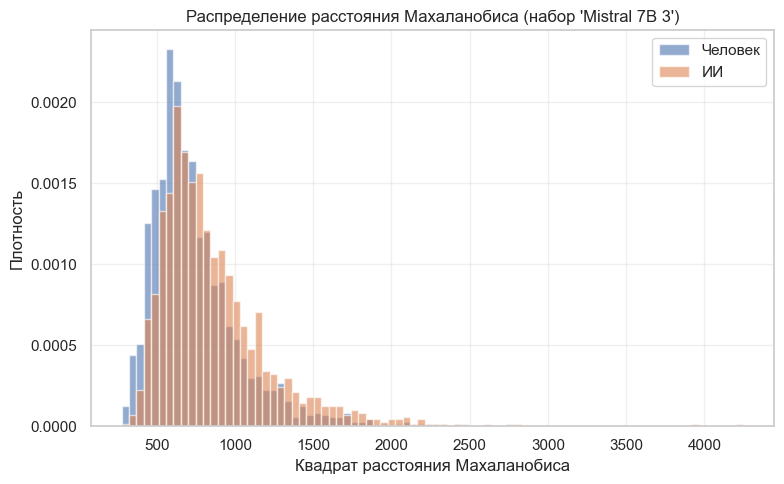

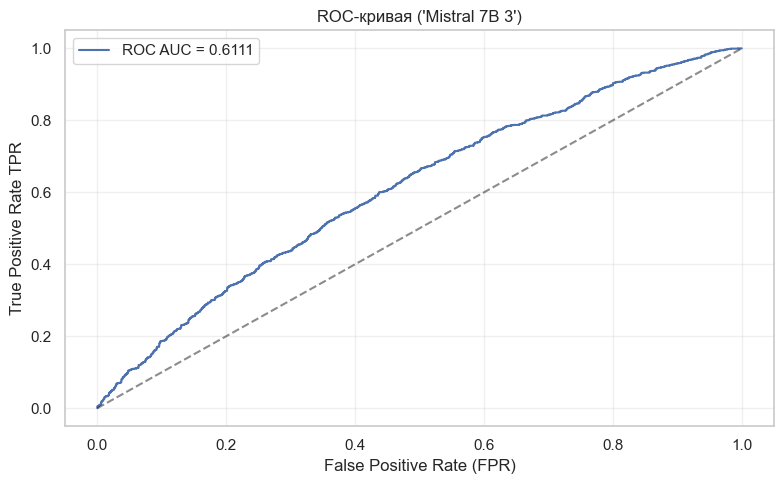

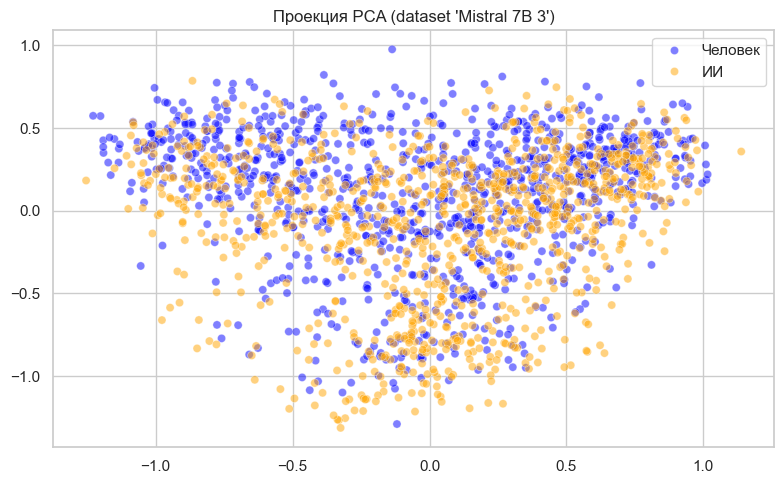


Набор: Mistral 7B 4
----------------------------------------


100%|███████████████████████████████████████████| 94/94 [01:36<00:00,  1.03s/it]


Статистики расстояния Махаланобиса (человек)
Среднее            |                     745.4394
Стд. отклонение    |                     292.3279
Асимметрия         |                       1.7572
Эксцесс            |                       4.6447
95% квантиль       |                    1296.6237
99% квантиль       |                    1781.0974

Статистики расстояния Махаланобиса (ии)
Среднее            |                     862.8934
Стд. отклонение    |                     370.9479
Асимметрия         |                       2.8837
Эксцесс            |                      18.3320
95% квантиль       |                    1588.0878
99% квантиль       |                    2130.9967

Количество объектов в 0 классе     : 3000
Количество объектов в 1 классе     : 1500
ROC-AUC                            : 0.6117
PR-AUC                             : 0.5933


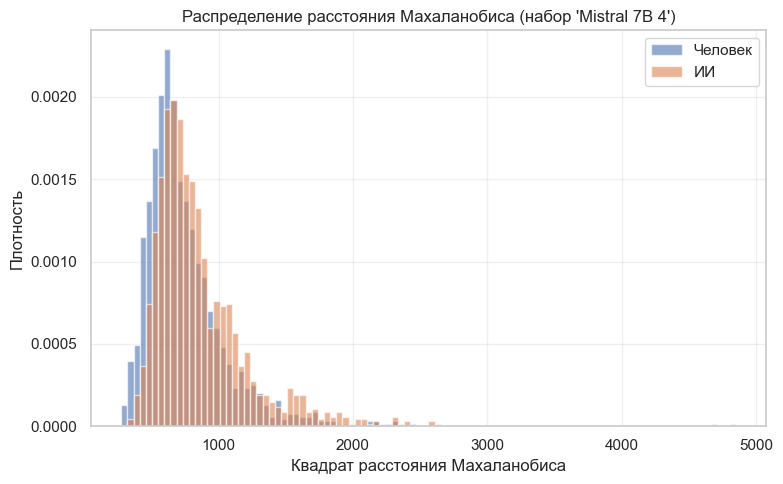

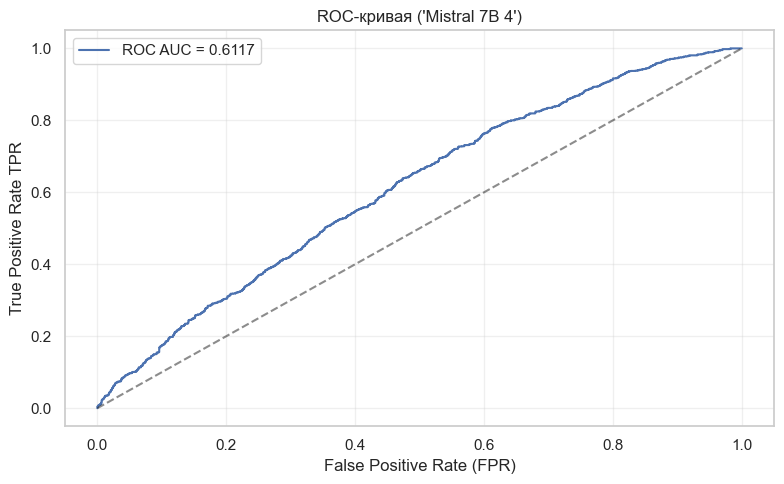

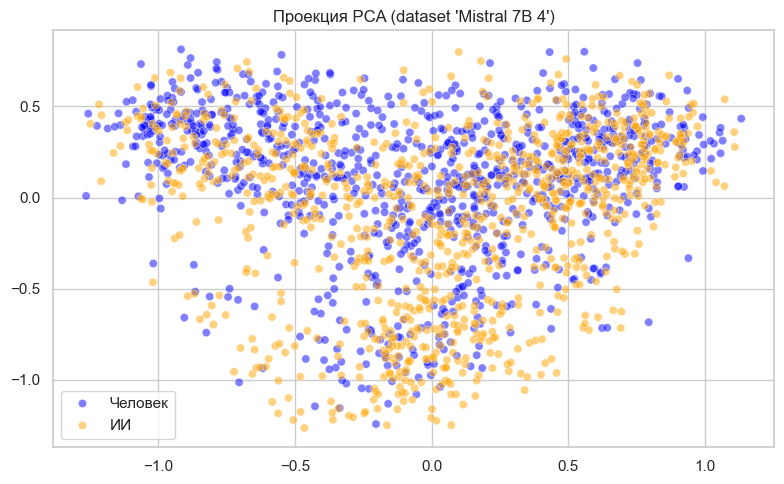


Набор: Mistral 7B 5
----------------------------------------


100%|███████████████████████████████████████████| 94/94 [01:37<00:00,  1.03s/it]


Статистики расстояния Махаланобиса (человек)
Среднее            |                     745.4394
Стд. отклонение    |                     292.3279
Асимметрия         |                       1.7572
Эксцесс            |                       4.6447
95% квантиль       |                    1296.6237
99% квантиль       |                    1781.0974

Статистики расстояния Махаланобиса (ии)
Среднее            |                     861.2749
Стд. отклонение    |                     331.5339
Асимметрия         |                       2.4016
Эксцесс            |                      10.1079
95% квантиль       |                    1451.7053
99% квантиль       |                    2077.2618

Количество объектов в 0 классе     : 3000
Количество объектов в 1 классе     : 1500
ROC-AUC                            : 0.6318
PR-AUC                             : 0.5941


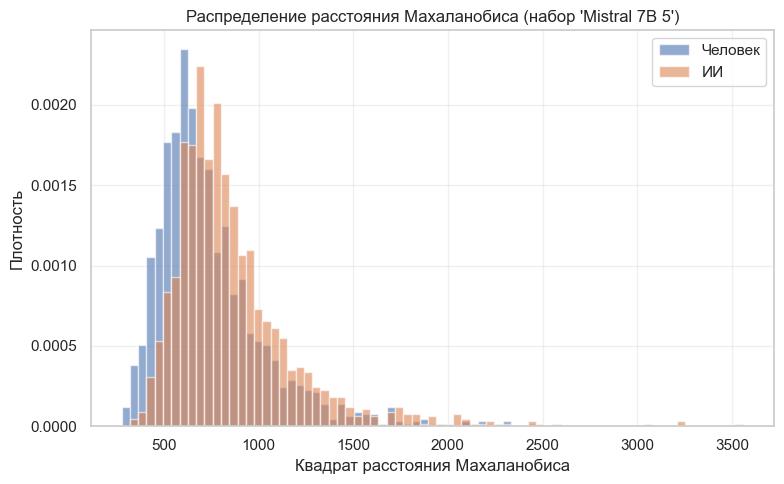

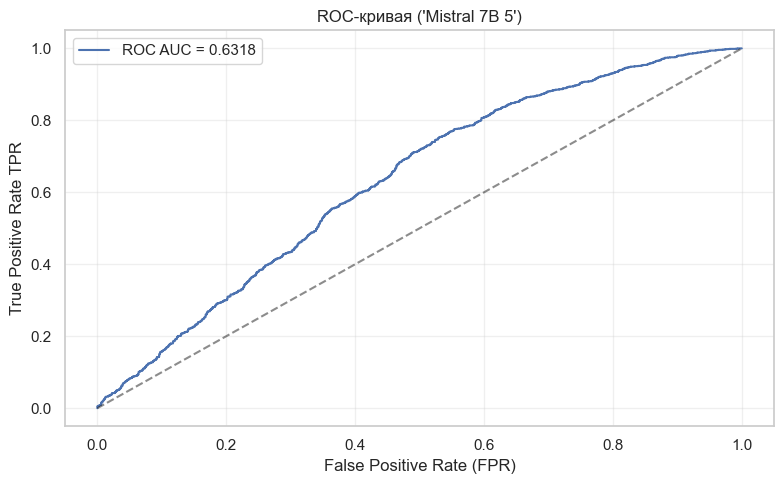

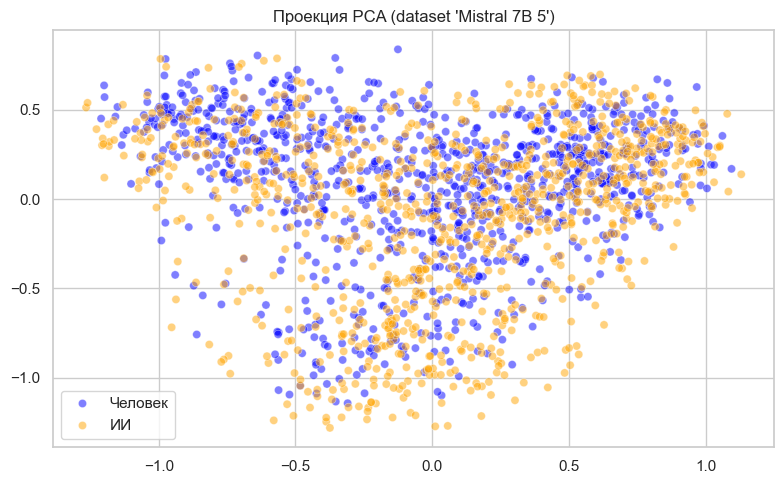


Набор: Llama 3 13B 1
----------------------------------------


100%|███████████████████████████████████████████| 63/63 [01:02<00:00,  1.00it/s]


Статистики расстояния Махаланобиса (человек)
Среднее            |                     750.5191
Стд. отклонение    |                     293.2384
Асимметрия         |                       1.7467
Эксцесс            |                       4.6078
95% квантиль       |                    1311.5798
99% квантиль       |                    1781.4087

Статистики расстояния Махаланобиса (ии)
Среднее            |                     868.5651
Стд. отклонение    |                     358.5763
Асимметрия         |                       3.6738
Эксцесс            |                      35.8646
95% квантиль       |                    1545.3492
99% квантиль       |                    2039.5067

Количество объектов в 0 классе     : 3000
Количество объектов в 1 классе     : 999
ROC-AUC                            : 0.6217
PR-AUC                             : 0.5952


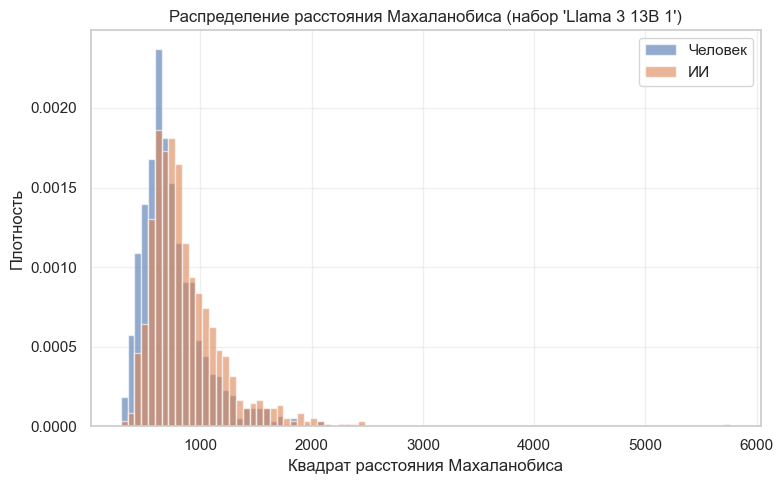

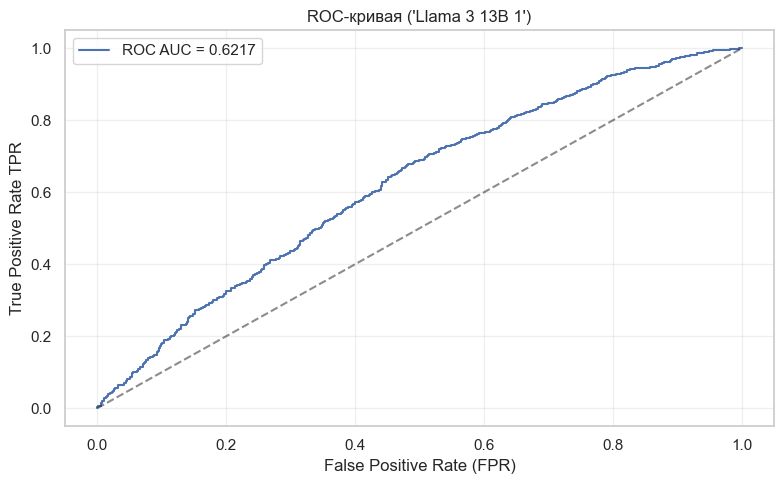

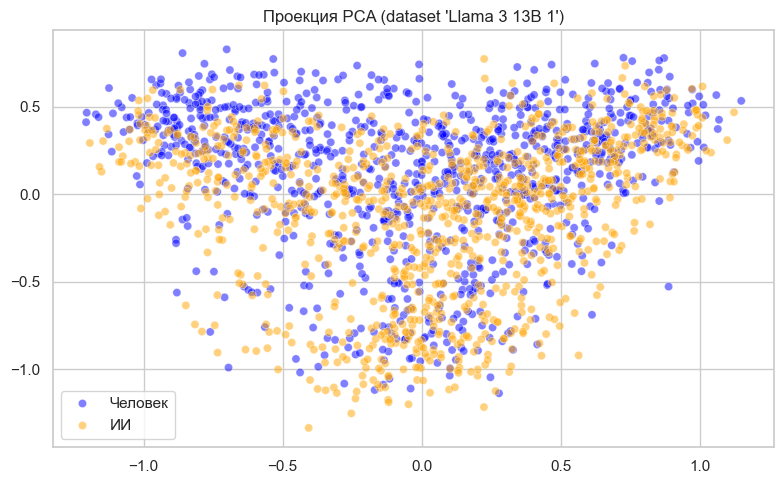


Набор: Llama 3 13B 2
----------------------------------------


100%|███████████████████████████████████████████| 63/63 [01:03<00:00,  1.01s/it]


Статистики расстояния Махаланобиса (человек)
Среднее            |                     750.4433
Стд. отклонение    |                     293.1015
Асимметрия         |                       1.7482
Эксцесс            |                       4.6162
95% квантиль       |                    1311.1812
99% квантиль       |                    1781.0974

Статистики расстояния Махаланобиса (ии)
Среднее            |                     897.2850
Стд. отклонение    |                     358.8302
Асимметрия         |                       2.5160
Эксцесс            |                      11.7727
95% квантиль       |                    1529.6958
99% квантиль       |                    2169.3418

Количество объектов в 0 классе     : 3000
Количество объектов в 1 классе     : 1000
ROC-AUC                            : 0.6518
PR-AUC                             : 0.6184


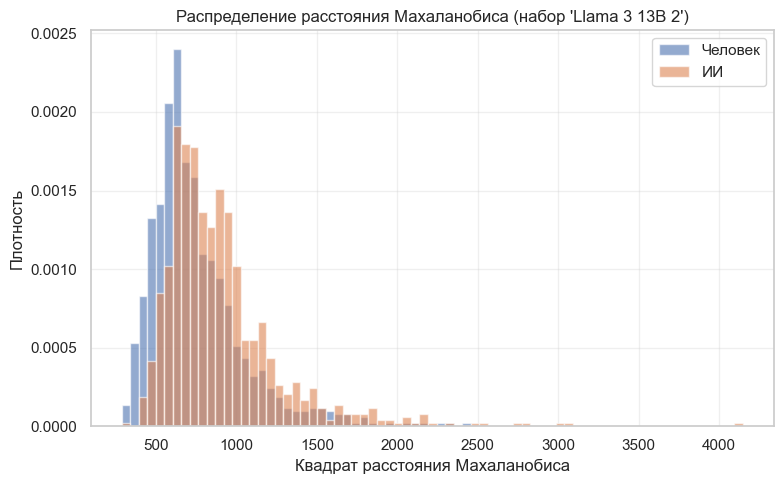

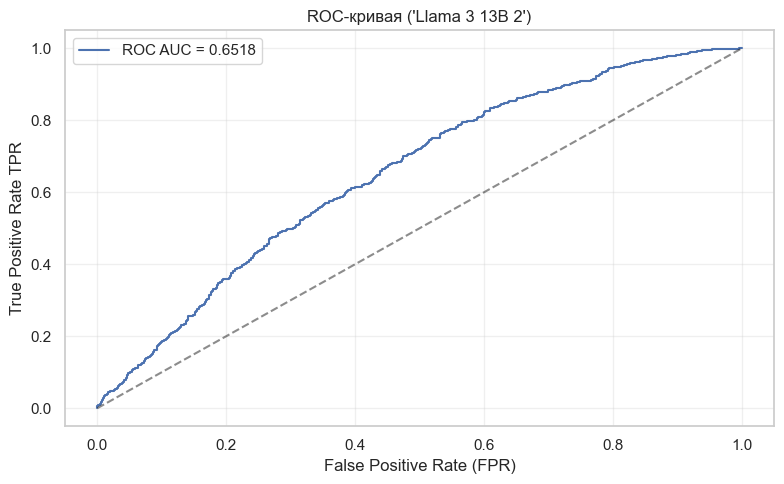

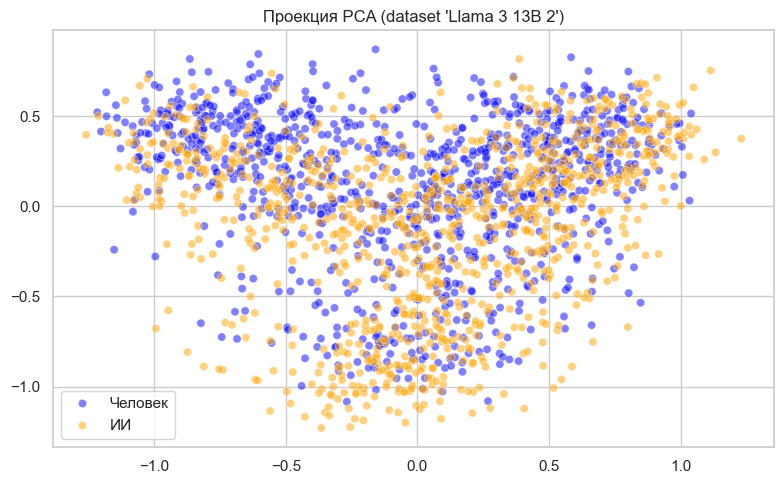


Набор: Llama 3 13B 3
----------------------------------------


100%|███████████████████████████████████████████| 63/63 [01:04<00:00,  1.02s/it]


Статистики расстояния Махаланобиса (человек)
Среднее            |                     750.7040
Стд. отклонение    |                     293.5700
Асимметрия         |                       1.7461
Эксцесс            |                       4.6039
95% квантиль       |                    1313.5732
99% квантиль       |                    1782.9654

Статистики расстояния Махаланобиса (ии)
Среднее            |                     872.1979
Стд. отклонение    |                     339.0179
Асимметрия         |                       1.6254
Эксцесс            |                       3.4259
95% квантиль       |                    1537.6230
99% квантиль       |                    2082.2961

Количество объектов в 0 классе     : 3000
Количество объектов в 1 классе     : 994
ROC-AUC                            : 0.6229
PR-AUC                             : 0.5989


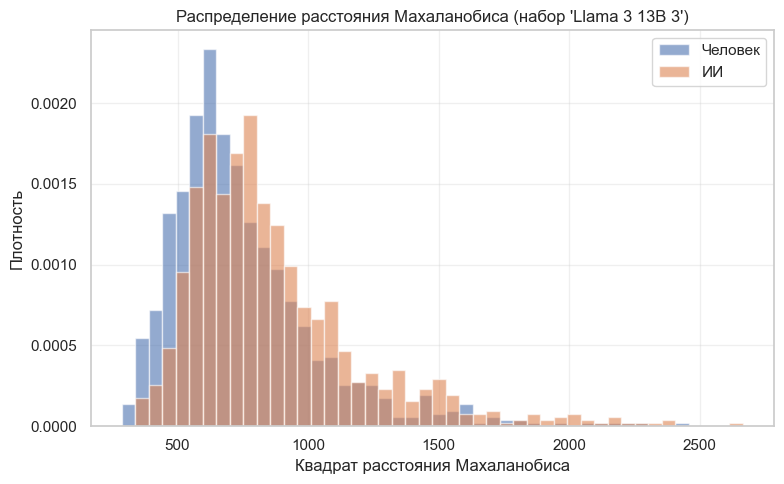

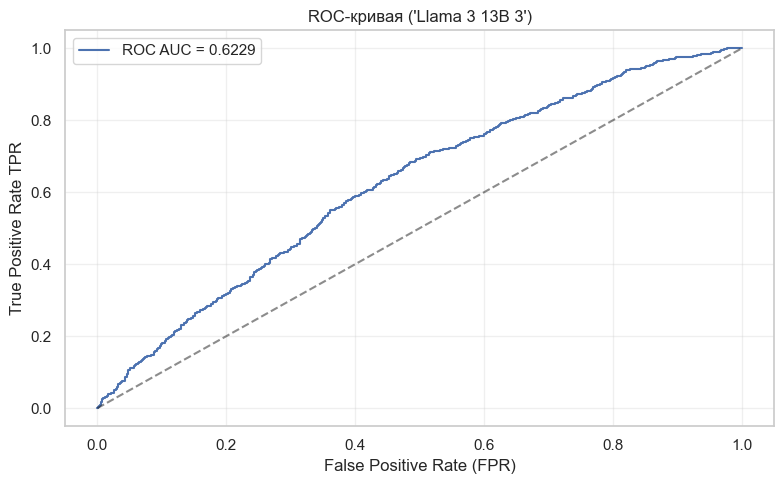

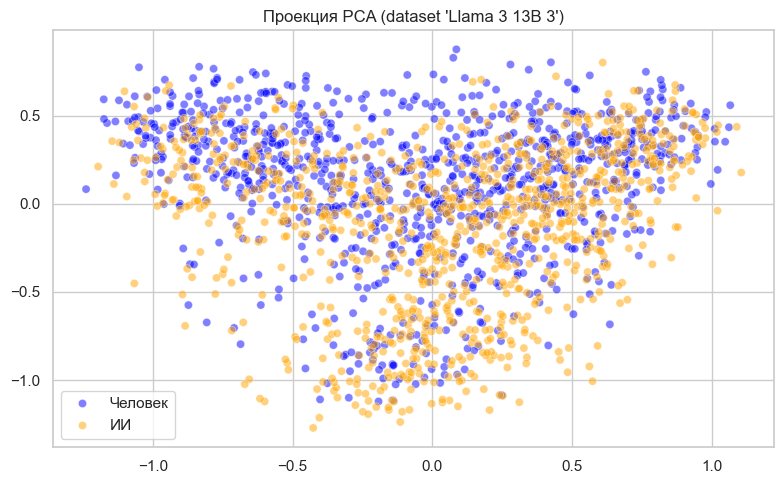


Набор: Llama 3 13B 4
----------------------------------------


100%|███████████████████████████████████████████| 63/63 [01:04<00:00,  1.02s/it]


Статистики расстояния Махаланобиса (человек)
Среднее            |                     750.2645
Стд. отклонение    |                     293.2521
Асимметрия         |                       1.7504
Эксцесс            |                       4.6247
95% квантиль       |                    1312.3772
99% квантиль       |                    1782.0314

Статистики расстояния Махаланобиса (ии)
Среднее            |                     857.0268
Стд. отклонение    |                     340.7137
Асимметрия         |                       2.1244
Эксцесс            |                       7.3855
95% квантиль       |                    1476.9794
99% квантиль       |                    2234.5885

Количество объектов в 0 классе     : 3000
Количество объектов в 1 классе     : 997
ROC-AUC                            : 0.6105
PR-AUC                             : 0.5878


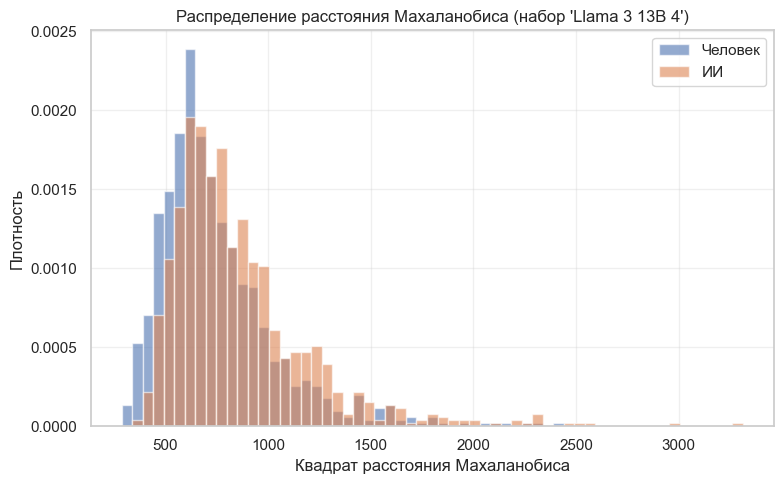

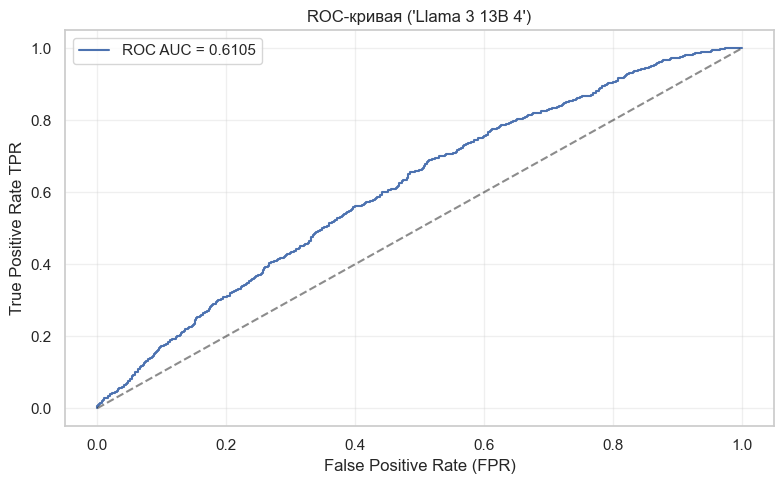

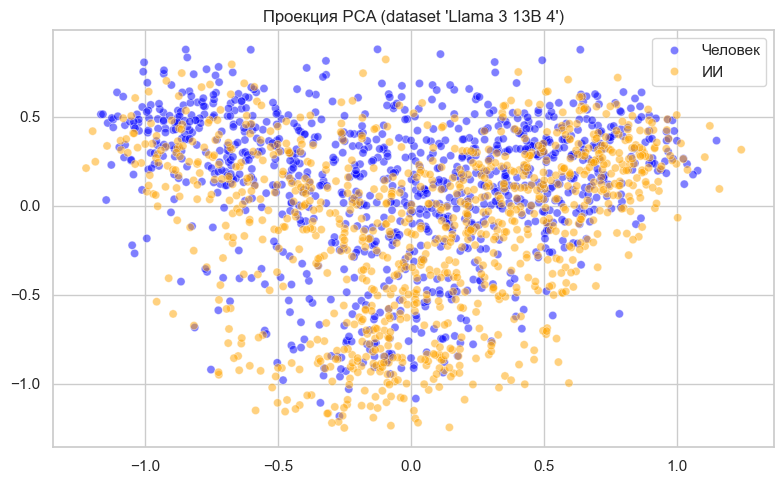


Набор: Llama 3 13B 5
----------------------------------------


100%|███████████████████████████████████████████| 63/63 [01:05<00:00,  1.04s/it]


Статистики расстояния Махаланобиса (человек)
Среднее            |                     750.5191
Стд. отклонение    |                     293.2384
Асимметрия         |                       1.7467
Эксцесс            |                       4.6078
95% квантиль       |                    1311.5798
99% квантиль       |                    1781.4087

Статистики расстояния Махаланобиса (ии)
Среднее            |                     840.5096
Стд. отклонение    |                     328.0822
Асимметрия         |                       2.1492
Эксцесс            |                       7.1839
95% квантиль       |                    1489.4186
99% квантиль       |                    2050.7621

Количество объектов в 0 классе     : 3000
Количество объектов в 1 классе     : 999
ROC-AUC                            : 0.5981
PR-AUC                             : 0.5726


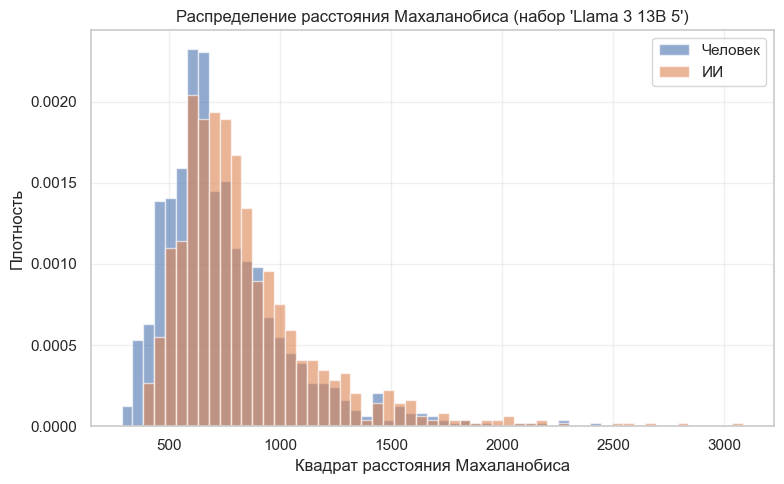

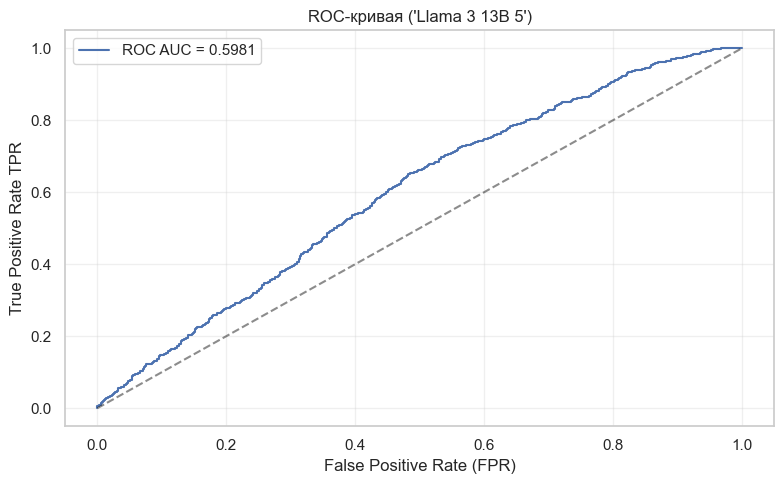

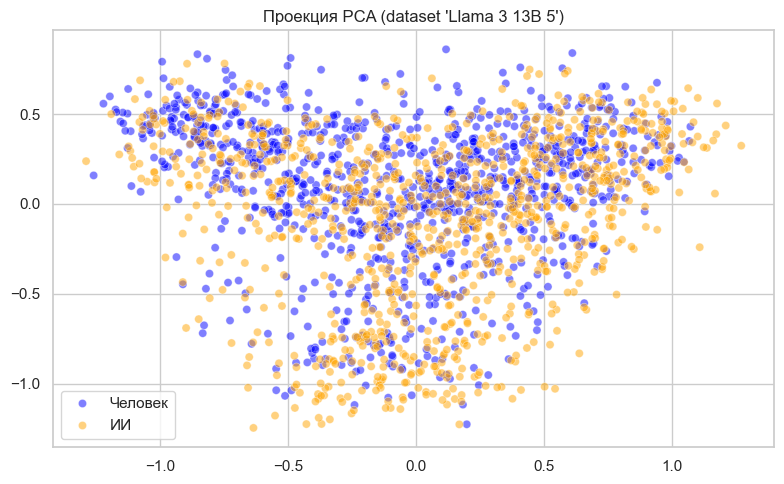


Набор: DeepSeek V3.2 1
----------------------------------------


100%|█████████████████████████████████████████| 188/188 [03:13<00:00,  1.03s/it]


Статистики расстояния Махаланобиса (человек)
Среднее            |                     745.3856
Стд. отклонение    |                     298.4764
Асимметрия         |                       1.8361
Эксцесс            |                       5.1532
95% квантиль       |                    1328.8893
99% квантиль       |                    1825.0186

Статистики расстояния Махаланобиса (ии)
Среднее            |                     797.5322
Стд. отклонение    |                     302.8195
Асимметрия         |                       2.1626
Эксцесс            |                       6.7230
95% квантиль       |                    1405.5723
99% квантиль       |                    1956.4178

Количество объектов в 0 классе     : 3000
Количество объектов в 1 классе     : 3000
ROC-AUC                            : 0.5681
PR-AUC                             : 0.5396


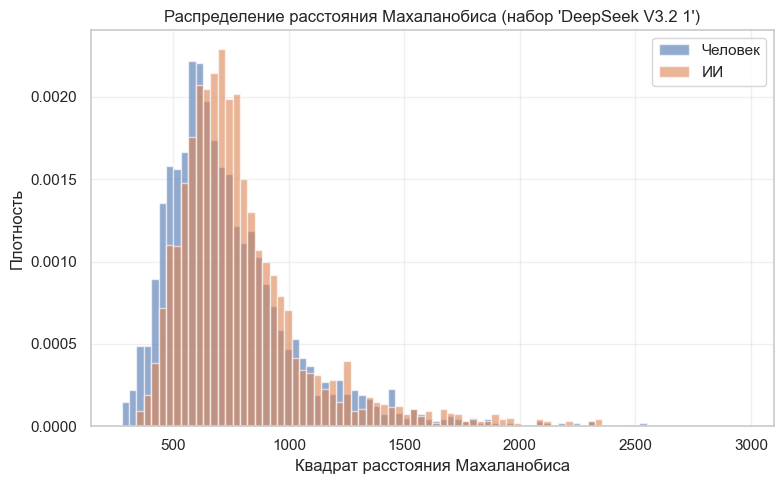

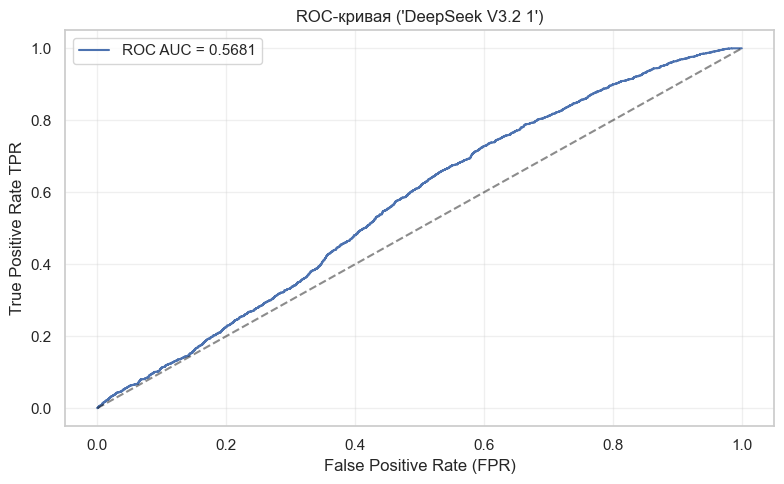

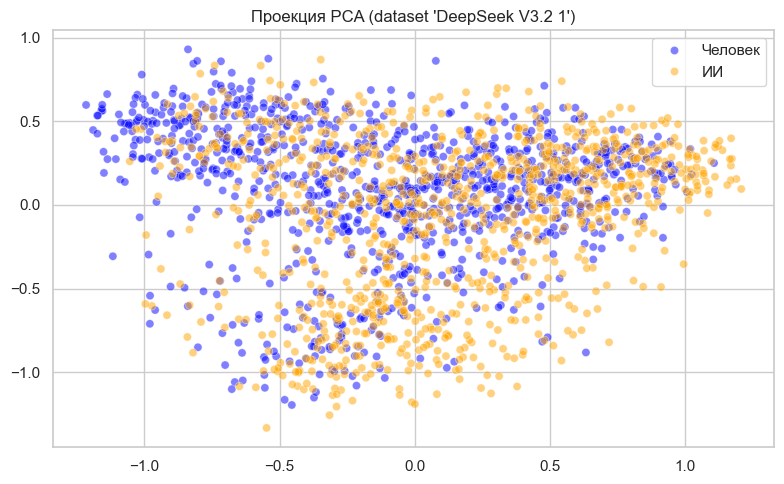


Набор: DeepSeek V3.2 2
----------------------------------------


100%|█████████████████████████████████████████| 188/188 [03:13<00:00,  1.03s/it]


Статистики расстояния Махаланобиса (человек)
Среднее            |                     745.3856
Стд. отклонение    |                     298.4764
Асимметрия         |                       1.8361
Эксцесс            |                       5.1532
95% квантиль       |                    1328.8893
99% квантиль       |                    1825.0186

Статистики расстояния Махаланобиса (ии)
Среднее            |                     803.9426
Стд. отклонение    |                     303.5362
Асимметрия         |                       2.0573
Эксцесс            |                       5.9079
95% квантиль       |                    1416.5496
99% квантиль       |                    1942.2341

Количество объектов в 0 классе     : 3000
Количество объектов в 1 классе     : 3000
ROC-AUC                            : 0.5738
PR-AUC                             : 0.5448


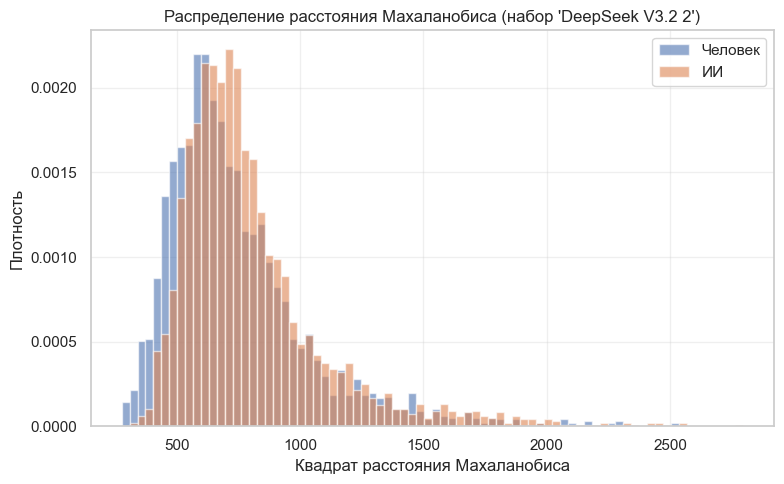

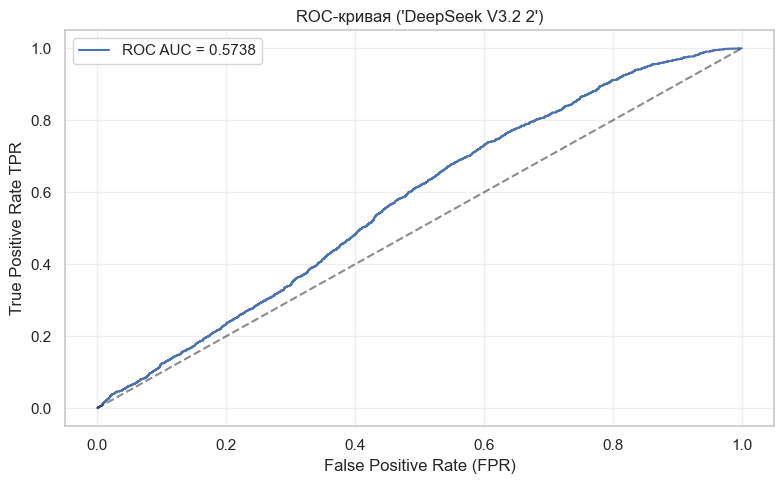

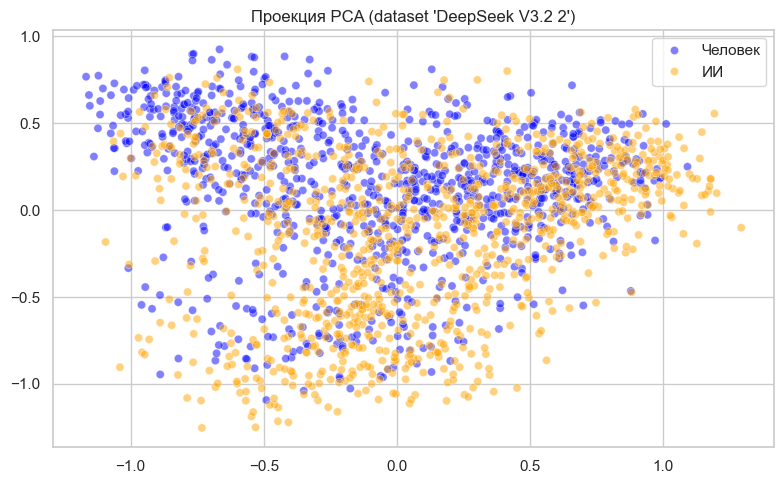


Набор: DeepSeek V3.2 3
----------------------------------------


100%|█████████████████████████████████████████| 188/188 [03:11<00:00,  1.02s/it]


Статистики расстояния Махаланобиса (человек)
Среднее            |                     745.5173
Стд. отклонение    |                     298.4389
Асимметрия         |                       1.8369
Эксцесс            |                       5.1558
95% квантиль       |                    1328.9232
99% квантиль       |                    1825.2817

Статистики расстояния Махаланобиса (ии)
Среднее            |                     805.9733
Стд. отклонение    |                     310.3411
Асимметрия         |                       2.1003
Эксцесс            |                       6.3458
95% квантиль       |                    1442.4681
99% квантиль       |                    1983.2640

Количество объектов в 0 классе     : 3000
Количество объектов в 1 классе     : 2999
ROC-AUC                            : 0.5736
PR-AUC                             : 0.5469


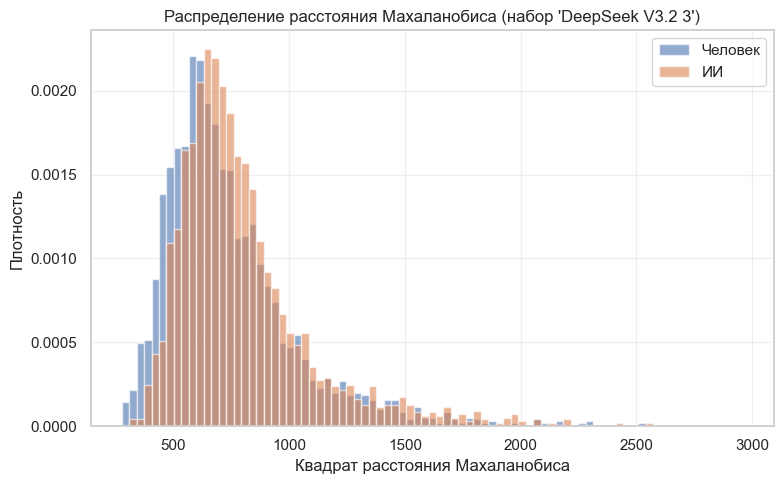

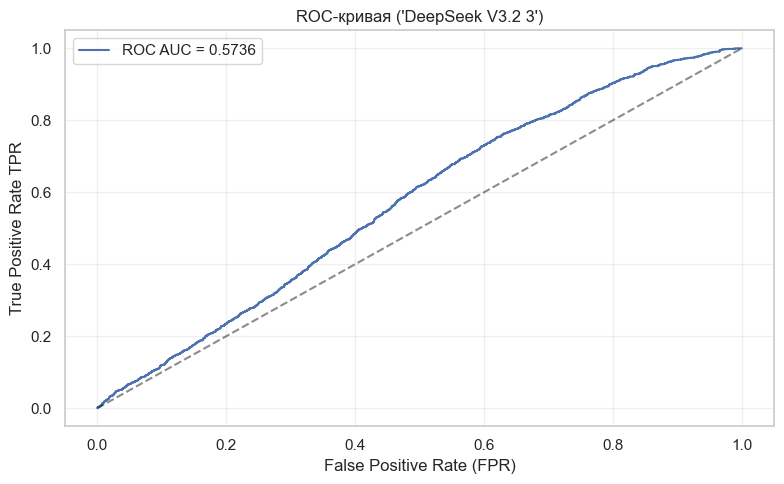

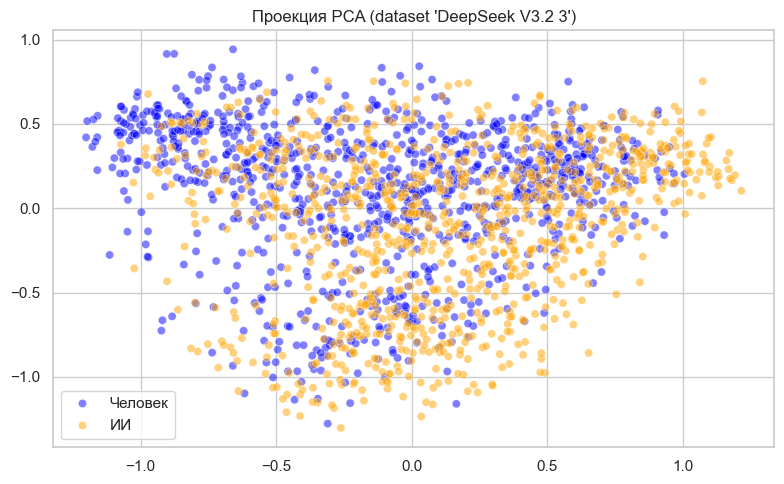


Набор: DeepSeek V3.2 4
----------------------------------------


100%|█████████████████████████████████████████| 188/188 [03:19<00:00,  1.06s/it]


Статистики расстояния Махаланобиса (человек)
Среднее            |                     745.3856
Стд. отклонение    |                     298.4764
Асимметрия         |                       1.8361
Эксцесс            |                       5.1532
95% квантиль       |                    1328.8893
99% квантиль       |                    1825.0186

Статистики расстояния Махаланобиса (ии)
Среднее            |                     812.5354
Стд. отклонение    |                     311.0573
Асимметрия         |                       2.2035
Эксцесс            |                       6.8366
95% квантиль       |                    1430.7065
99% квантиль       |                    2060.7932

Количество объектов в 0 классе     : 3000
Количество объектов в 1 классе     : 3000
ROC-AUC                            : 0.5826
PR-AUC                             : 0.5518


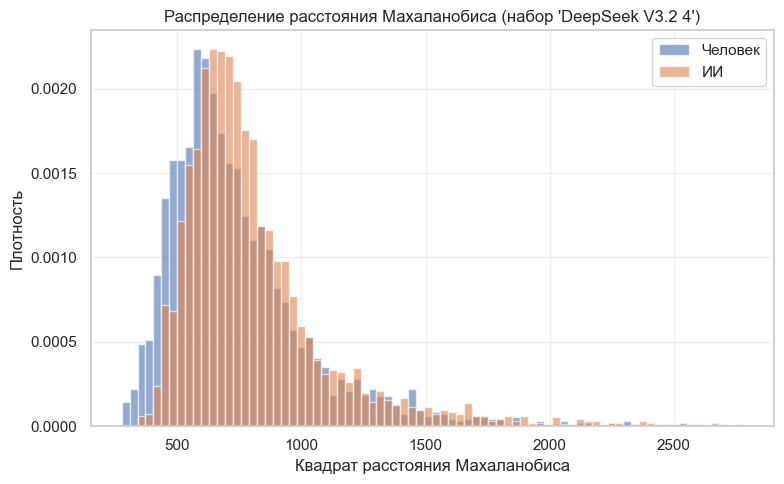

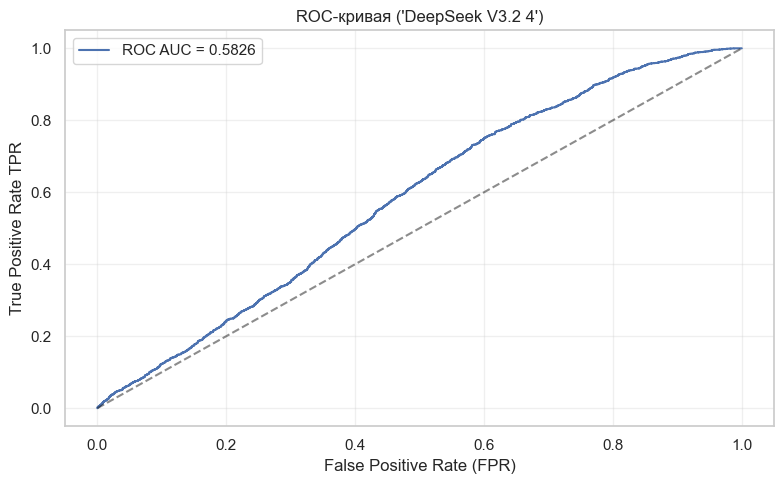

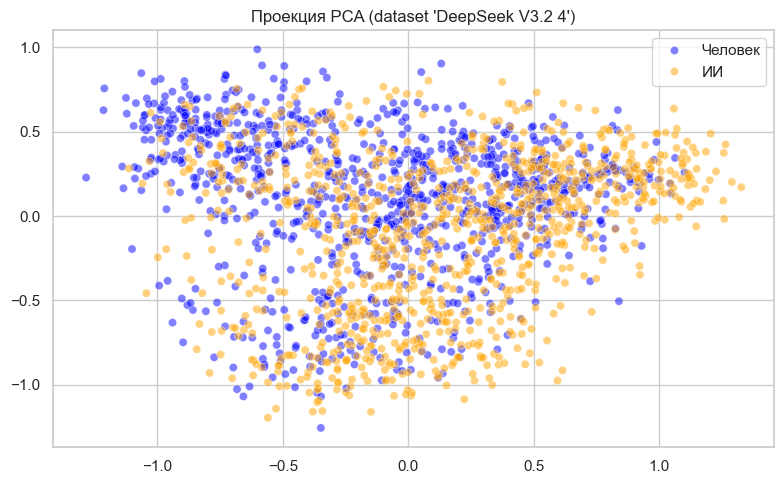


Набор: DeepSeek V3.2 5
----------------------------------------


100%|█████████████████████████████████████████| 188/188 [03:20<00:00,  1.07s/it]


Статистики расстояния Махаланобиса (человек)
Среднее            |                     745.3856
Стд. отклонение    |                     298.4764
Асимметрия         |                       1.8361
Эксцесс            |                       5.1532
95% квантиль       |                    1328.8893
99% квантиль       |                    1825.0186

Статистики расстояния Махаланобиса (ии)
Среднее            |                     806.4410
Стд. отклонение    |                     282.6319
Асимметрия         |                       2.2763
Эксцесс            |                       8.4408
95% квантиль       |                    1363.1024
99% квантиль       |                    1875.9114

Количество объектов в 0 классе     : 3000
Количество объектов в 1 классе     : 3000
ROC-AUC                            : 0.5901
PR-AUC                             : 0.5457


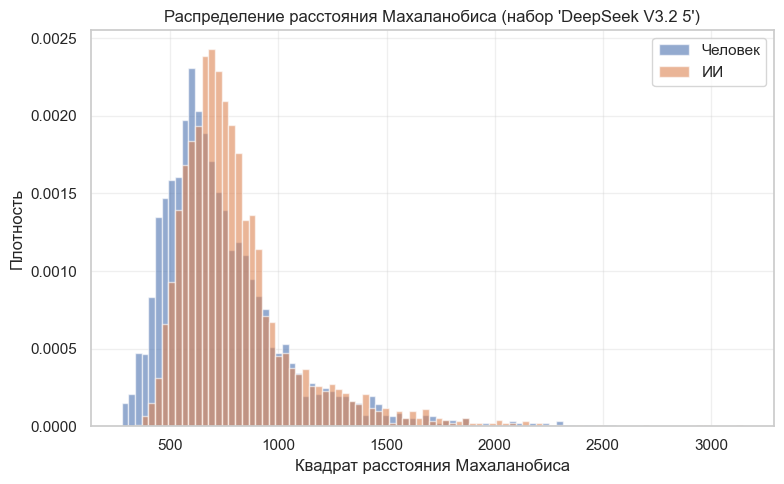

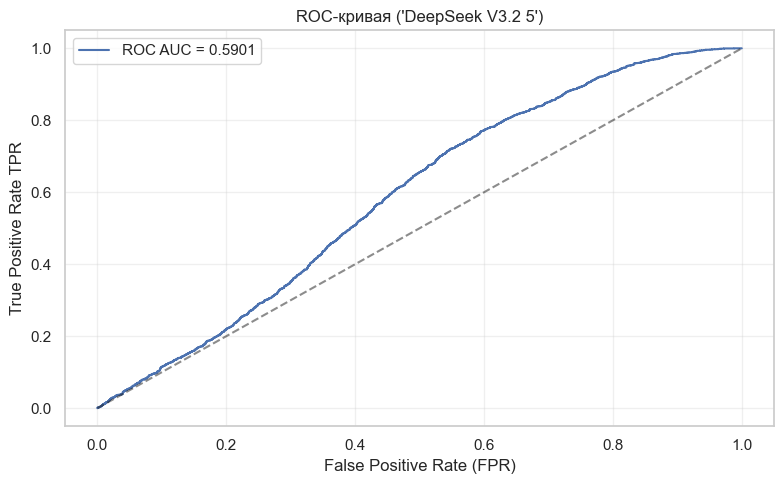

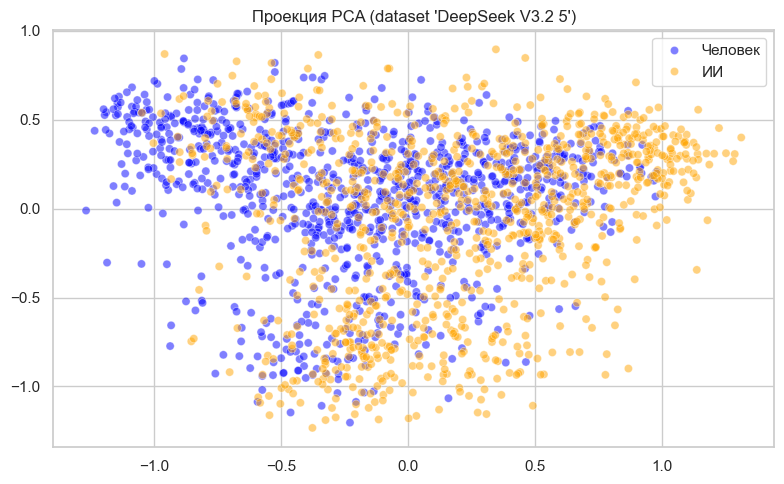


Набор: ChatGPT 1
----------------------------------------


100%|█████████████████████████████████████████| 125/125 [02:12<00:00,  1.06s/it]


Статистики расстояния Махаланобиса (человек)
Среднее            |                     747.3496
Стд. отклонение    |                     296.3102
Асимметрия         |                       1.8080
Эксцесс            |                       4.9816
95% квантиль       |                    1307.1722
99% квантиль       |                    1815.4651

Статистики расстояния Махаланобиса (ии)
Среднее            |                     835.5938
Стд. отклонение    |                     322.1770
Асимметрия         |                       1.9502
Эксцесс            |                       5.3883
95% квантиль       |                    1469.7689
99% квантиль       |                    2071.1704

Количество объектов в 0 классе     : 3000
Количество объектов в 1 классе     : 2000
ROC-AUC                            : 0.6005
PR-AUC                             : 0.5709


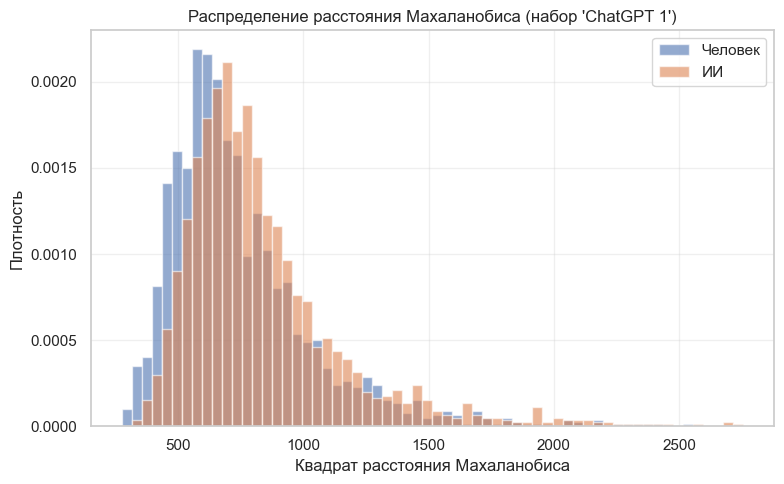

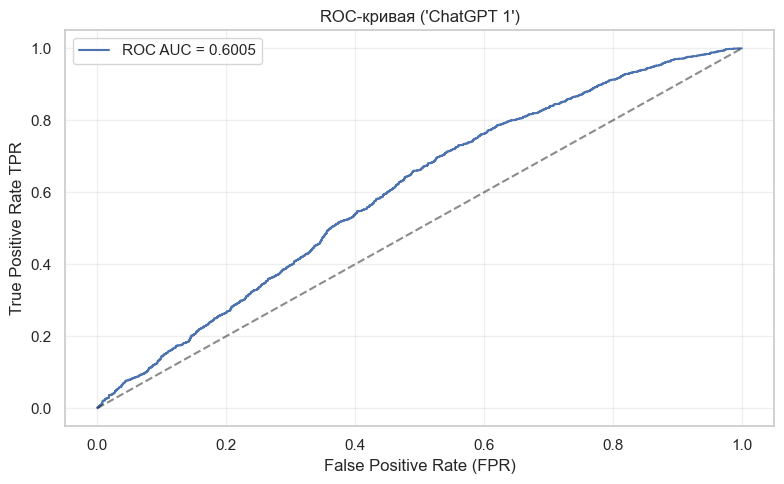

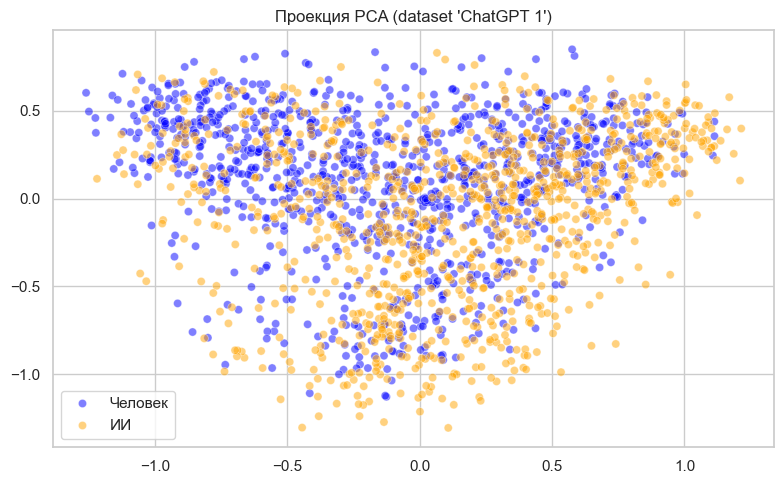


Набор: ChatGPT 2
----------------------------------------


100%|█████████████████████████████████████████| 125/125 [02:15<00:00,  1.08s/it]


Статистики расстояния Махаланобиса (человек)
Среднее            |                     747.3496
Стд. отклонение    |                     296.3102
Асимметрия         |                       1.8080
Эксцесс            |                       4.9816
95% квантиль       |                    1307.1722
99% квантиль       |                    1815.4651

Статистики расстояния Махаланобиса (ии)
Среднее            |                     834.1275
Стд. отклонение    |                     318.7849
Асимметрия         |                       1.8462
Эксцесс            |                       5.0693
95% квантиль       |                    1476.2164
99% квантиль       |                    1996.9696

Количество объектов в 0 классе     : 3000
Количество объектов в 1 классе     : 2000
ROC-AUC                            : 0.5994
PR-AUC                             : 0.5706


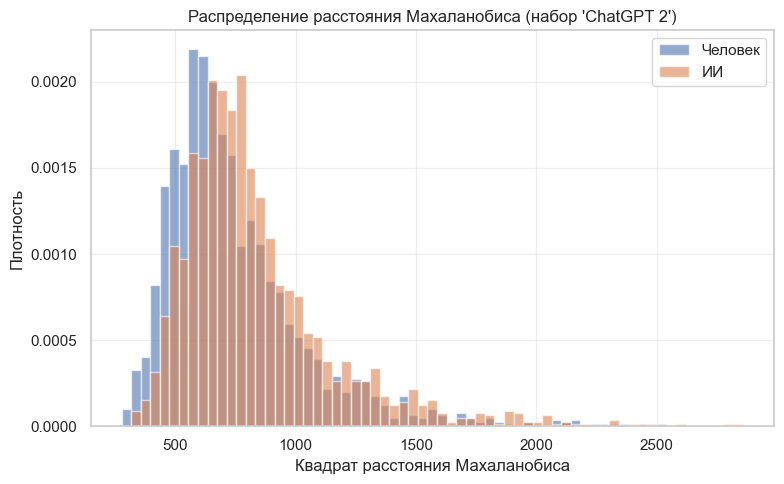

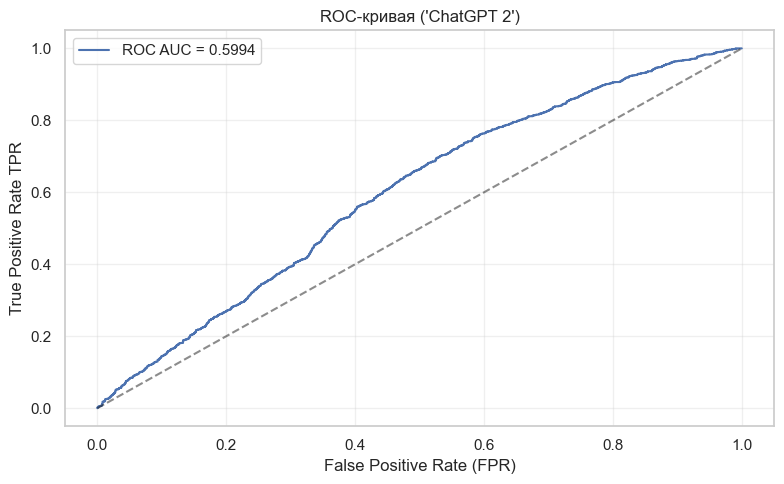

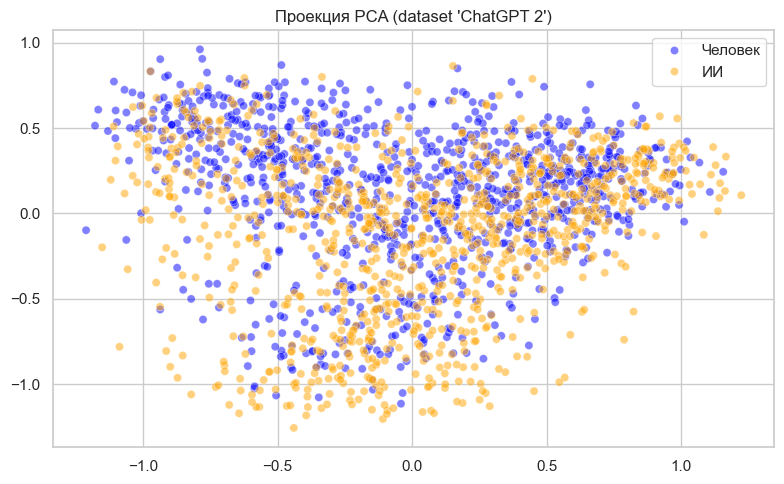


Набор: ChatGPT 3
----------------------------------------


100%|█████████████████████████████████████████| 125/125 [02:14<00:00,  1.08s/it]


Статистики расстояния Махаланобиса (человек)
Среднее            |                     747.3496
Стд. отклонение    |                     296.3102
Асимметрия         |                       1.8080
Эксцесс            |                       4.9816
95% квантиль       |                    1307.1722
99% квантиль       |                    1815.4651

Статистики расстояния Махаланобиса (ии)
Среднее            |                     839.2186
Стд. отклонение    |                     324.9913
Асимметрия         |                       1.9790
Эксцесс            |                       6.0835
95% квантиль       |                    1476.4400
99% квантиль       |                    2048.0330

Количество объектов в 0 классе     : 3000
Количество объектов в 1 классе     : 2000
ROC-AUC                            : 0.6033
PR-AUC                             : 0.5744


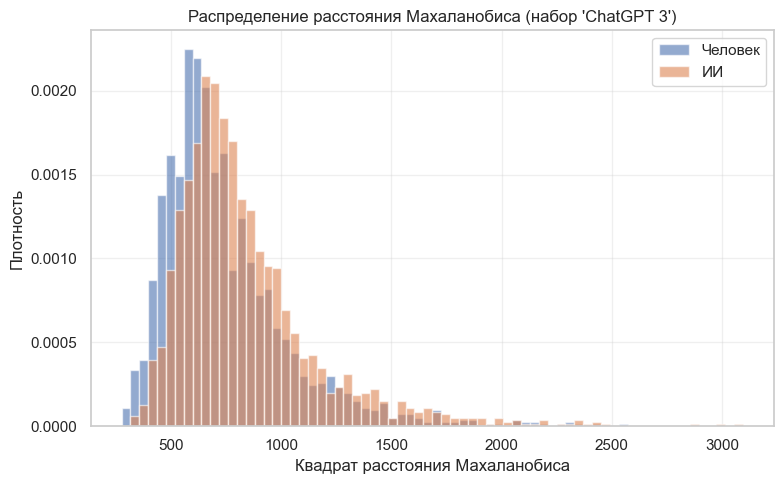

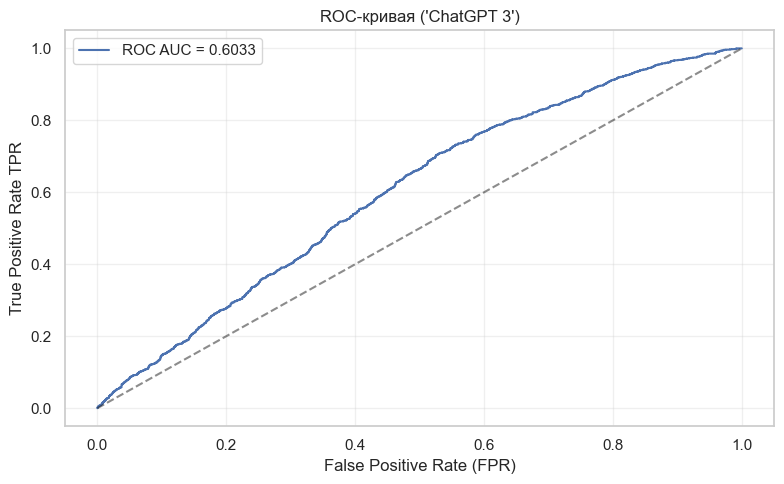

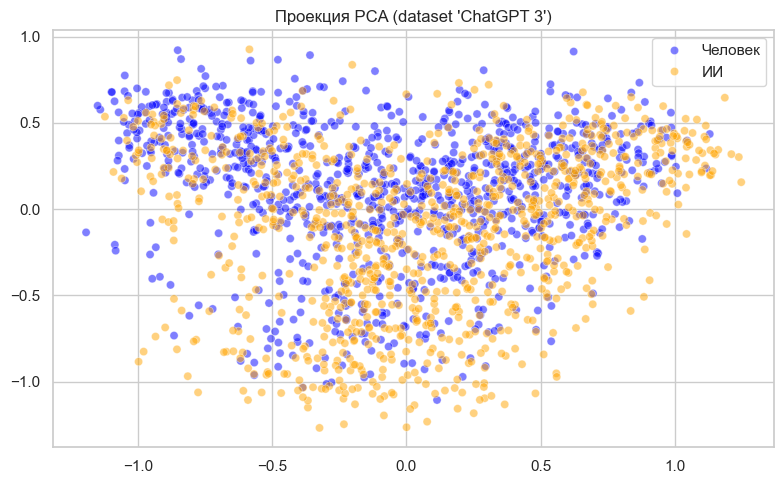


Набор: ChatGPT 4
----------------------------------------


100%|█████████████████████████████████████████| 125/125 [01:59<00:00,  1.04it/s]


Статистики расстояния Махаланобиса (человек)
Среднее            |                     747.3496
Стд. отклонение    |                     296.3102
Асимметрия         |                       1.8080
Эксцесс            |                       4.9816
95% квантиль       |                    1307.1722
99% квантиль       |                    1815.4651

Статистики расстояния Махаланобиса (ии)
Среднее            |                     866.2499
Стд. отклонение    |                     341.1386
Асимметрия         |                       2.0869
Эксцесс            |                       6.8046
95% квантиль       |                    1564.9637
99% квантиль       |                    2100.5171

Количество объектов в 0 классе     : 3000
Количество объектов в 1 классе     : 2000
ROC-AUC                            : 0.6273
PR-AUC                             : 0.5955


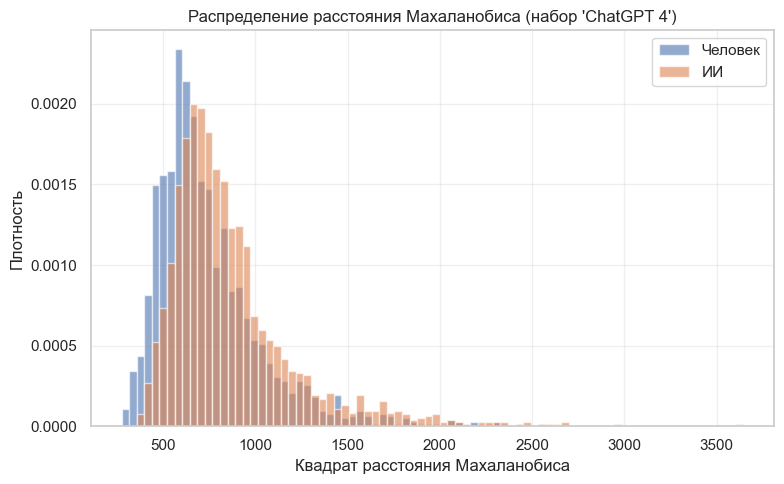

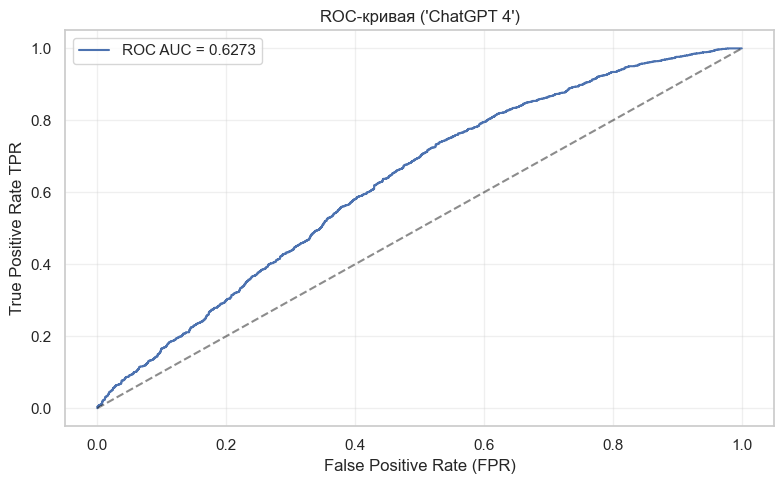

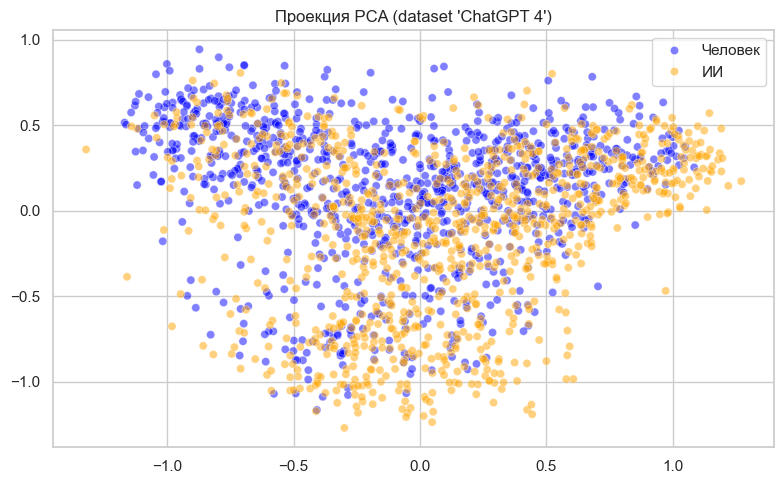


Набор: ChatGPT 5
----------------------------------------


100%|█████████████████████████████████████████| 125/125 [01:26<00:00,  1.44it/s]


Статистики расстояния Махаланобиса (человек)
Среднее            |                     747.3496
Стд. отклонение    |                     296.3102
Асимметрия         |                       1.8080
Эксцесс            |                       4.9816
95% квантиль       |                    1307.1722
99% квантиль       |                    1815.4651

Статистики расстояния Махаланобиса (ии)
Среднее            |                     844.6458
Стд. отклонение    |                     307.0897
Асимметрия         |                       2.0508
Эксцесс            |                       6.7887
95% квантиль       |                    1447.9810
99% квантиль       |                    1968.2891

Количество объектов в 0 классе     : 3000
Количество объектов в 1 классе     : 2000
ROC-AUC                            : 0.6209
PR-AUC                             : 0.5789


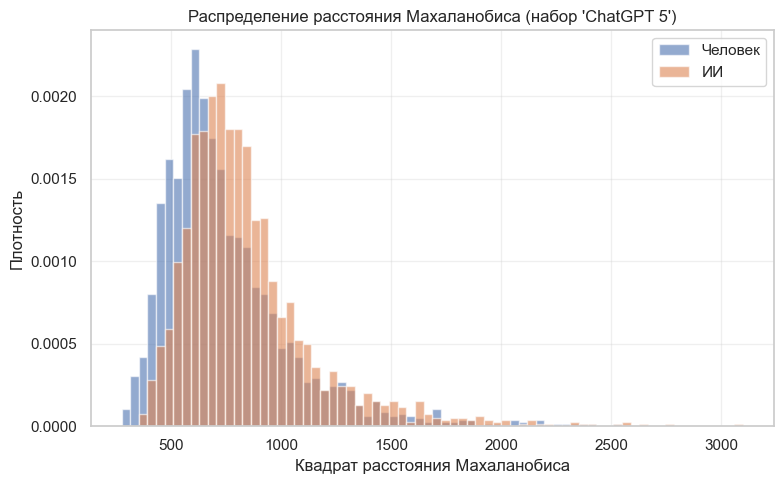

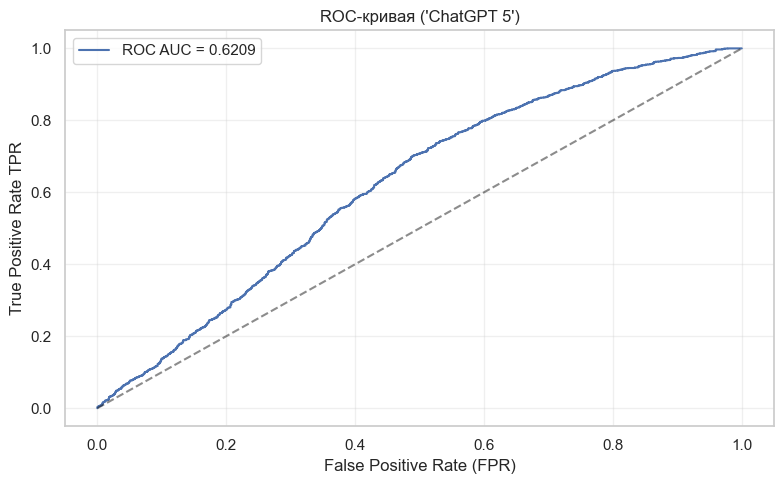

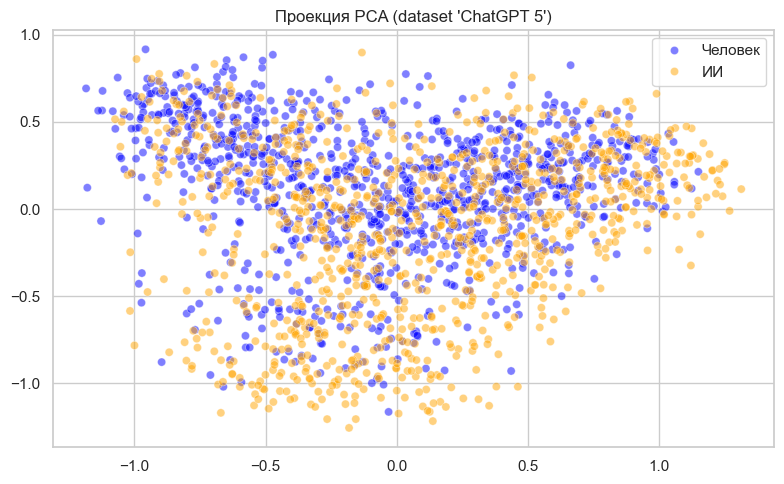

In [7]:
results = []

print_header(f"ENCODER: {ENCODER}")

tokenizer = AutoTokenizer.from_pretrained(ENCODER)
model = AutoModel.from_pretrained(ENCODER)

X_human = get_embeddings(tokenizer, model, human_df["text"])
X_human = X_human.numpy().astype(np.float32)

print_norm_stats(X_human)

X_h_train, X_h_test = train_test_split(
    X_human,
    test_size=0.3,
    random_state=SEED
)

print_kv("Эмбеддинги живых текстов (train)", len(X_h_train))
print_kv("Эмбеддинги живых текстов (test)", len(X_h_test))

cov = LedoitWolf().fit(X_h_train)
scores_h_train = cov.mahalanobis(X_h_train)

covariance_spectrum(cov)

for name, ai_df in ai_datasets.items():
    print(f"\nНабор: {name}")
    print("-" * 40)

    X_ai = get_embeddings(tokenizer, model, ai_df["text"])
    X_ai = X_ai.numpy().astype(np.float32)

    n = min(len(X_h_test), len(X_ai))

    X_test = np.vstack([X_h_test[:n], X_ai[:n]])
    y_test = np.concatenate([
        np.zeros(n, dtype=int),
        np.ones(n, dtype=int)
    ])

    scores = cov.mahalanobis(X_test)
    scores_human = scores[:n]
    scores_ai = scores[n:]

    print_mahalanobis_stats(scores_human, "человек")
    print_mahalanobis_stats(scores_ai, "ии")

    roc_auc = roc_auc_score(y_test, scores)
    ap = average_precision_score(y_test, scores)

    print_kv("Количество объектов в 0 классе", len(X_h_test))
    print_kv("Количество объектов в 1 классе", len(X_ai))
    print_kv("ROC-AUC", f"{roc_auc:.4f}")
    print_kv("PR-AUC", f"{ap:.4f}")

    plot_mahalanobis_distributions(scores_human, scores_ai, name)
    plot_roc_curve(y_test, scores, roc_auc, name)
    plot_pca_projection(X_h_test, X_ai, name)

    results.append({
        "dataset": name,
        "size": len(X_test),
        "roc_auc": roc_auc,
        "pr_auc": ap
    })

In [8]:
results_df = pd.DataFrame(results)
print(results_df)

            dataset  size   roc_auc    pr_auc
0      Mistral 7B 1  3000  0.608019  0.591951
1      Mistral 7B 2  3000  0.637064  0.609009
2      Mistral 7B 3  3000  0.611147  0.596080
3      Mistral 7B 4  3000  0.611700  0.593322
4      Mistral 7B 5  3000  0.631798  0.594097
5     Llama 3 13B 1  1998  0.621717  0.595246
6     Llama 3 13B 2  2000  0.651755  0.618414
7     Llama 3 13B 3  1988  0.622921  0.598917
8     Llama 3 13B 4  1994  0.610513  0.587766
9     Llama 3 13B 5  1998  0.598148  0.572570
10  DeepSeek V3.2 1  6000  0.568110  0.539553
11  DeepSeek V3.2 2  6000  0.573810  0.544794
12  DeepSeek V3.2 3  5998  0.573568  0.546867
13  DeepSeek V3.2 4  6000  0.582633  0.551782
14  DeepSeek V3.2 5  6000  0.590117  0.545678
15        ChatGPT 1  4000  0.600538  0.570930
16        ChatGPT 2  4000  0.599433  0.570558
17        ChatGPT 3  4000  0.603302  0.574376
18        ChatGPT 4  4000  0.627295  0.595470
19        ChatGPT 5  4000  0.620902  0.578917
